# GPT

# Yelp

In [2]:
!pip install nltk

  Using cached nltk-3.9.1-py3-none-any.whl.metadata (2.9 kB)
Using cached nltk-3.9.1-py3-none-any.whl (1.5 MB)


[nltk_data] Downloading package wordnet to /home/jovyan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/jovyan/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Epoch 8, Train Acc: 0.9526, Val Acc: 0.7661, Test Acc: 0.7697


Epoch 9 Training: 100%|██████████| 2629/2629 [03:44<00:00, 11.70it/s]


Epoch 9, Train Acc: 0.9629, Val Acc: 0.7639, Test Acc: 0.7711


Epoch 10 Training: 100%|██████████| 2629/2629 [03:43<00:00, 11.78it/s]


Epoch 10, Train Acc: 0.9711, Val Acc: 0.7669, Test Acc: 0.7767


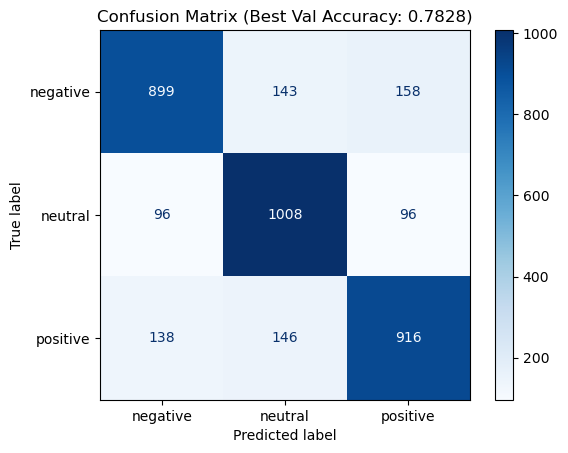

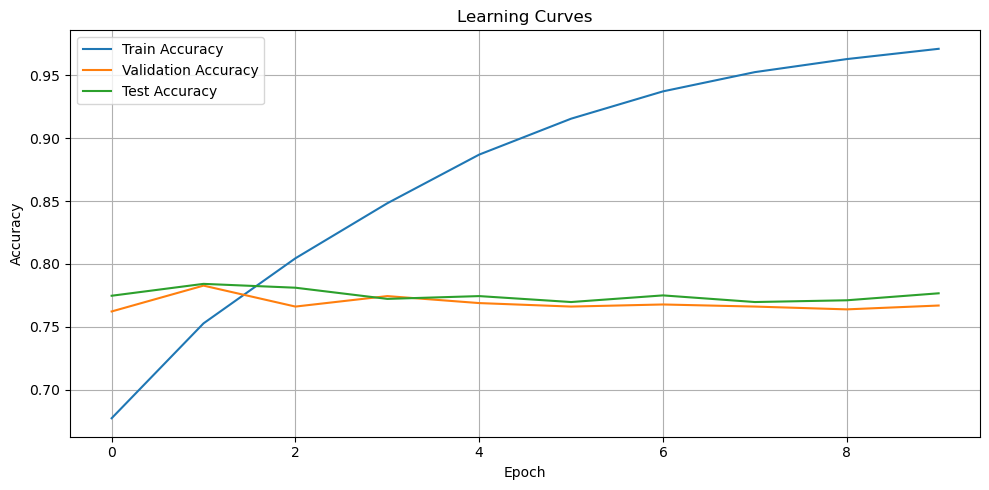

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from transformers import GPT2Tokenizer, GPT2ForSequenceClassification, get_scheduler
from torch.optim import AdamW
from tqdm import tqdm
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer
import logging

# ------------------- Suppress Warnings -------------------
logging.getLogger("transformers.modeling_utils").setLevel(logging.ERROR)

# ------------------- NLTK Setup -------------------
for resource in ['punkt', 'wordnet', 'averaged_perceptron_tagger']:
    try:
        nltk.data.find(f'tokenizers/{resource}' if resource == 'punkt' else f'corpora/{resource}')
    except LookupError:
        nltk.download(resource)

lemmatizer = WordNetLemmatizer()
def get_wordnet_pos(tag):
    if tag.startswith('J'): return wordnet.ADJ
    elif tag.startswith('V'): return wordnet.VERB
    elif tag.startswith('N'): return wordnet.NOUN
    elif tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

def tokenize_text(text):
    tokens = word_tokenize(text.lower())
    return [lemmatizer.lemmatize(w, get_wordnet_pos(t)) for w, t in pos_tag(tokens)]

# ------------------- Load & Preprocess Data -------------------
train_file = "./data/yelp/train.csv"
val_file = "./data/yelp/dev.csv"
test_file = "./data/yelp/test.csv"

def load_data(train_file, val_file, test_file):
    train_df = pd.read_csv(train_file)[['text', 'label']].dropna()
    val_df = pd.read_csv(val_file)[['text', 'label']].dropna()
    test_df = pd.read_csv(test_file)[['text', 'label']].dropna()
    return train_df, val_df, test_df

data_train, data_val, data_test = load_data(train_file, val_file, test_file)

# Label encode
le = LabelEncoder()
data_train['label'] = le.fit_transform(data_train['label'])
data_val['label'] = le.transform(data_val['label'])
data_test['label'] = le.transform(data_test['label'])

# ------------------- GPT-2 Dataset -------------------
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token  # Add pad token manually for GPT2

class GPT2SentimentDataset(Dataset):
    def __init__(self, texts, labels, max_len=128):
        self.encodings = tokenizer(
            texts.tolist(), truncation=True, padding='max_length', max_length=max_len, return_tensors='pt'
        )
        self.labels = torch.tensor(labels.tolist(), dtype=torch.long)

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'label': self.labels[idx]
        }

train_dataset = GPT2SentimentDataset(data_train['text'], data_train['label'])
val_dataset = GPT2SentimentDataset(data_val['text'], data_val['label'])
test_dataset = GPT2SentimentDataset(data_test['text'], data_test['label'])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

# ------------------- GPT-2 Model -------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GPT2ForSequenceClassification.from_pretrained("gpt2", num_labels=len(le.classes_))
model.resize_token_embeddings(len(tokenizer))
model.config.pad_token_id = tokenizer.pad_token_id
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)
scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=30 * len(train_loader))

# ------------------- Train Model -------------------
def train_model(model, train_loader, val_loader, test_loader, epochs=10):
    train_acc_list, val_acc_list, test_acc_list = [], [], []
    best_val_acc = 0
    best_preds, best_labels = [], []

    for epoch in range(epochs):
        model.train()
        total, correct = 0, 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            scheduler.step()

            preds = outputs.logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total
        train_acc_list.append(train_acc)

        # --------- Validation ---------
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['label'].to(device)
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                preds = outputs.logits.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total
        val_acc_list.append(val_acc)
        best_val_acc = max(best_val_acc, val_acc)

        # --------- Testing ---------
        test_correct, test_total = 0, 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in test_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['label'].to(device)
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                preds = outputs.logits.argmax(dim=1)
                test_correct += (preds == labels).sum().item()
                test_total += labels.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        test_acc = test_correct / test_total
        test_acc_list.append(test_acc)

        if val_acc == best_val_acc:
            best_preds = all_preds
            best_labels = all_labels

        print(f"Epoch {epoch+1}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}")

    torch.save(model.state_dict(), "./gpt2_yelp.pth")

    # --------- Confusion Matrix ---------
    cm = confusion_matrix(best_labels, best_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix (Best Val Accuracy: {best_val_acc:.4f})")
    plt.show()

    # --------- Learning Curve ---------
    plt.figure(figsize=(10, 5))
    plt.plot(train_acc_list, label="Train Accuracy")
    plt.plot(val_acc_list, label="Validation Accuracy")
    plt.plot(test_acc_list, label="Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Learning Curves")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ------------------- Run -------------------
train_model(model, train_loader, val_loader, test_loader)


# dynabench

[nltk_data] Downloading package wordnet to /home/jovyan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/jovyan/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
Epoch 1 Training: 100%|██████████| 459/459 [00:39<00:00, 11.62it/s]


Epoch 1, Train Acc: 0.6385, Val Acc: 0.6236, Test Acc: 0.6444


Epoch 2 Training: 100%|██████████| 459/459 [00:39<00:00, 11.58it/s]


Epoch 2, Train Acc: 0.7770, Val Acc: 0.6319, Test Acc: 0.6458


Epoch 3 Training: 100%|██████████| 459/459 [00:39<00:00, 11.62it/s]


...

Epoch 8, Train Acc: 0.9570, Val Acc: 0.6528, Test Acc: 0.6750


Epoch 9 Training: 100%|██████████| 459/459 [00:39<00:00, 11.60it/s]


Epoch 9, Train Acc: 0.9763, Val Acc: 0.6542, Test Acc: 0.6833


Epoch 10 Training: 100%|██████████| 459/459 [00:39<00:00, 11.60it/s]


Epoch 10, Train Acc: 0.9813, Val Acc: 0.6583, Test Acc: 0.6944


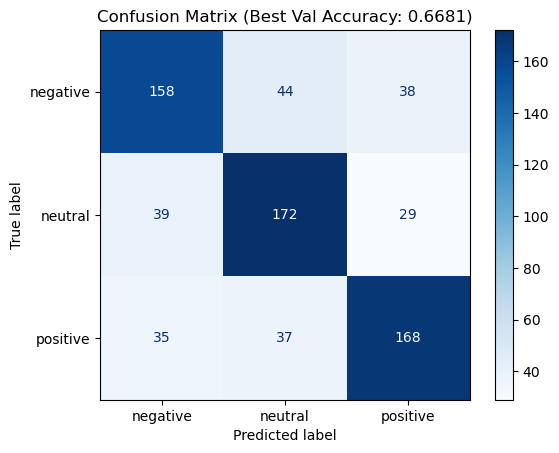

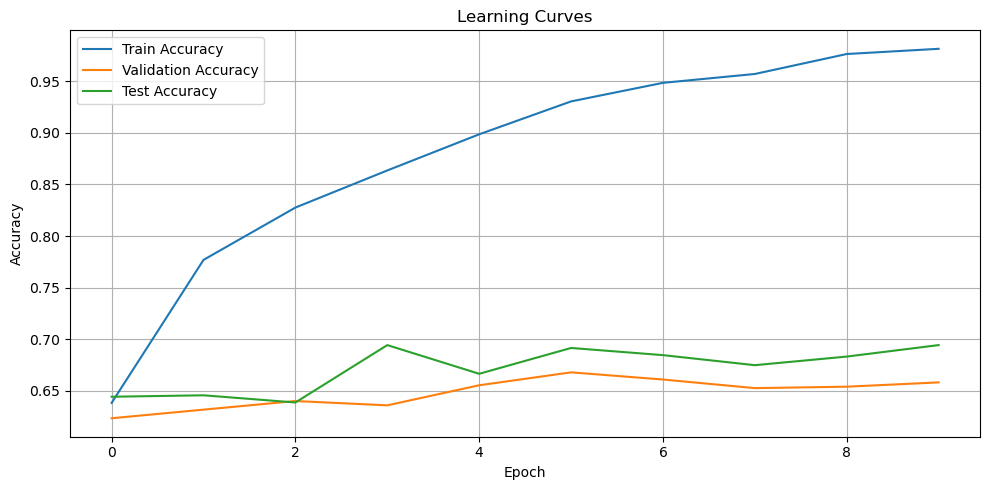

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from transformers import GPT2Tokenizer, GPT2ForSequenceClassification, get_scheduler
from torch.optim import AdamW
from tqdm import tqdm
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer
import logging

# ------------------- Suppress Warnings -------------------
logging.getLogger("transformers.modeling_utils").setLevel(logging.ERROR)

# ------------------- NLTK Setup -------------------
for resource in ['punkt', 'wordnet', 'averaged_perceptron_tagger']:
    try:
        nltk.data.find(f'tokenizers/{resource}' if resource == 'punkt' else f'corpora/{resource}')
    except LookupError:
        nltk.download(resource)

lemmatizer = WordNetLemmatizer()
def get_wordnet_pos(tag):
    if tag.startswith('J'): return wordnet.ADJ
    elif tag.startswith('V'): return wordnet.VERB
    elif tag.startswith('N'): return wordnet.NOUN
    elif tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

def tokenize_text(text):
    tokens = word_tokenize(text.lower())
    return [lemmatizer.lemmatize(w, get_wordnet_pos(t)) for w, t in pos_tag(tokens)]

# ------------------- Load & Preprocess Data -------------------
train_file = "./data/dynabench/train.csv"
val_file = "./data/dynabench/dev.csv"
test_file = "./data/dynabench/test.csv"

def load_data(train_file, val_file, test_file):
    train_df = pd.read_csv(train_file)[['text', 'label']].dropna()
    val_df = pd.read_csv(val_file)[['text', 'label']].dropna()
    test_df = pd.read_csv(test_file)[['text', 'label']].dropna()
    return train_df, val_df, test_df

data_train, data_val, data_test = load_data(train_file, val_file, test_file)

# Label encode
le = LabelEncoder()
data_train['label'] = le.fit_transform(data_train['label'])
data_val['label'] = le.transform(data_val['label'])
data_test['label'] = le.transform(data_test['label'])

# ------------------- GPT-2 Dataset -------------------
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token  # Add pad token manually for GPT2

class GPT2SentimentDataset(Dataset):
    def __init__(self, texts, labels, max_len=128):
        self.encodings = tokenizer(
            texts.tolist(), truncation=True, padding='max_length', max_length=max_len, return_tensors='pt'
        )
        self.labels = torch.tensor(labels.tolist(), dtype=torch.long)

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'label': self.labels[idx]
        }

train_dataset = GPT2SentimentDataset(data_train['text'], data_train['label'])
val_dataset = GPT2SentimentDataset(data_val['text'], data_val['label'])
test_dataset = GPT2SentimentDataset(data_test['text'], data_test['label'])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

# ------------------- GPT-2 Model -------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GPT2ForSequenceClassification.from_pretrained("gpt2", num_labels=len(le.classes_))
model.resize_token_embeddings(len(tokenizer))
model.config.pad_token_id = tokenizer.pad_token_id
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)
scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=30 * len(train_loader))

# ------------------- Train Model -------------------
def train_model(model, train_loader, val_loader, test_loader, epochs=10):
    train_acc_list, val_acc_list, test_acc_list = [], [], []
    best_val_acc = 0
    best_preds, best_labels = [], []

    for epoch in range(epochs):
        model.train()
        total, correct = 0, 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            scheduler.step()

            preds = outputs.logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total
        train_acc_list.append(train_acc)

        # --------- Validation ---------
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['label'].to(device)
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                preds = outputs.logits.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total
        val_acc_list.append(val_acc)
        best_val_acc = max(best_val_acc, val_acc)

        # --------- Testing ---------
        test_correct, test_total = 0, 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in test_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['label'].to(device)
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                preds = outputs.logits.argmax(dim=1)
                test_correct += (preds == labels).sum().item()
                test_total += labels.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        test_acc = test_correct / test_total
        test_acc_list.append(test_acc)

        if val_acc == best_val_acc:
            best_preds = all_preds
            best_labels = all_labels

        print(f"Epoch {epoch+1}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}")

    torch.save(model.state_dict(), "./gpt2_dynabench.pth")

    # --------- Confusion Matrix ---------
    cm = confusion_matrix(best_labels, best_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix (Best Val Accuracy: {best_val_acc:.4f})")
    plt.show()

    # --------- Learning Curve ---------
    plt.figure(figsize=(10, 5))
    plt.plot(train_acc_list, label="Train Accuracy")
    plt.plot(val_acc_list, label="Validation Accuracy")
    plt.plot(test_acc_list, label="Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Learning Curves")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ------------------- Run -------------------
train_model(model, train_loader, val_loader, test_loader)


# yelp_dyanbench_2500

[nltk_data] Downloading package wordnet to /home/jovyan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/jovyan/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
Epoch 1 Training: 100%|██████████| 3088/3088 [04:22<00:00, 11.75it/s]


Epoch 1, Train Acc: 0.6781, Val Acc: 0.6722, Test Acc: 0.6979


Epoch 2 Training: 100%|██████████| 3088/3088 [04:21<00:00, 11.81it/s]


Epoch 2, Train Acc: 0.7556, Val Acc: 0.6833, Test Acc: 0.7083


Epoch 3 Training: 100%|██████████| 3088/3088 [04:21<00:00, 11.80it/s]


...

Epoch 8, Train Acc: 0.9498, Val Acc: 0.6951, Test Acc: 0.7243


Epoch 9 Training: 100%|██████████| 3088/3088 [04:22<00:00, 11.78it/s]


Epoch 9, Train Acc: 0.9624, Val Acc: 0.6965, Test Acc: 0.7243


Epoch 10 Training: 100%|██████████| 3088/3088 [04:22<00:00, 11.76it/s]


Epoch 10, Train Acc: 0.9687, Val Acc: 0.6917, Test Acc: 0.7139


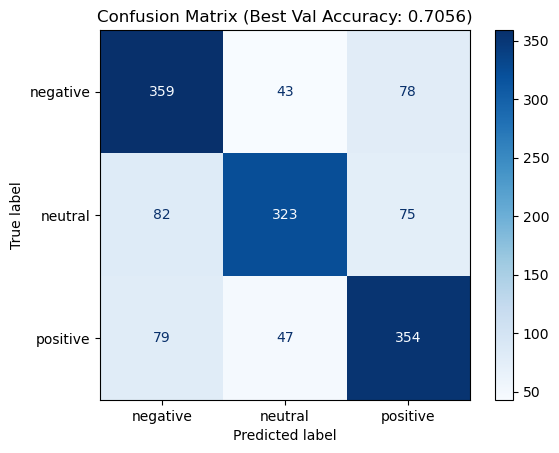

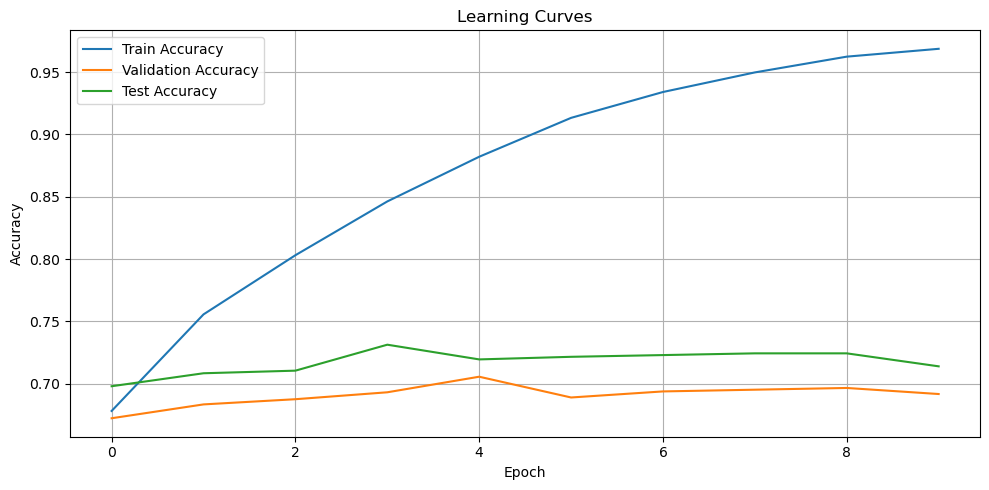

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from transformers import GPT2Tokenizer, GPT2ForSequenceClassification, get_scheduler
from torch.optim import AdamW
from tqdm import tqdm
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer
import logging

# ------------------- Suppress Warnings -------------------
logging.getLogger("transformers.modeling_utils").setLevel(logging.ERROR)

# ------------------- NLTK Setup -------------------
for resource in ['punkt', 'wordnet', 'averaged_perceptron_tagger']:
    try:
        nltk.data.find(f'tokenizers/{resource}' if resource == 'punkt' else f'corpora/{resource}')
    except LookupError:
        nltk.download(resource)

lemmatizer = WordNetLemmatizer()
def get_wordnet_pos(tag):
    if tag.startswith('J'): return wordnet.ADJ
    elif tag.startswith('V'): return wordnet.VERB
    elif tag.startswith('N'): return wordnet.NOUN
    elif tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

def tokenize_text(text):
    tokens = word_tokenize(text.lower())
    return [lemmatizer.lemmatize(w, get_wordnet_pos(t)) for w, t in pos_tag(tokens)]

# ------------------- Load & Preprocess Data -------------------
train_file = "./data/yelp_dynabench_2500/train.csv"
val_file = "./data/yelp_dynabench_2500/dev.csv"
test_file = "./data/yelp_dynabench_2500/test.csv"

def load_data(train_file, val_file, test_file):
    train_df = pd.read_csv(train_file)[['text', 'label']].dropna()
    val_df = pd.read_csv(val_file)[['text', 'label']].dropna()
    test_df = pd.read_csv(test_file)[['text', 'label']].dropna()
    return train_df, val_df, test_df

data_train, data_val, data_test = load_data(train_file, val_file, test_file)

# Label encode
le = LabelEncoder()
data_train['label'] = le.fit_transform(data_train['label'])
data_val['label'] = le.transform(data_val['label'])
data_test['label'] = le.transform(data_test['label'])

# ------------------- GPT-2 Dataset -------------------
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token  # Add pad token manually for GPT2

class GPT2SentimentDataset(Dataset):
    def __init__(self, texts, labels, max_len=128):
        self.encodings = tokenizer(
            texts.tolist(), truncation=True, padding='max_length', max_length=max_len, return_tensors='pt'
        )
        self.labels = torch.tensor(labels.tolist(), dtype=torch.long)

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'label': self.labels[idx]
        }

train_dataset = GPT2SentimentDataset(data_train['text'], data_train['label'])
val_dataset = GPT2SentimentDataset(data_val['text'], data_val['label'])
test_dataset = GPT2SentimentDataset(data_test['text'], data_test['label'])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

# ------------------- GPT-2 Model -------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GPT2ForSequenceClassification.from_pretrained("gpt2", num_labels=len(le.classes_))
model.resize_token_embeddings(len(tokenizer))
model.config.pad_token_id = tokenizer.pad_token_id
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)
scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=30 * len(train_loader))

# ------------------- Train Model -------------------
def train_model(model, train_loader, val_loader, test_loader, epochs=10):
    train_acc_list, val_acc_list, test_acc_list = [], [], []
    best_val_acc = 0
    best_preds, best_labels = [], []

    for epoch in range(epochs):
        model.train()
        total, correct = 0, 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            scheduler.step()

            preds = outputs.logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total
        train_acc_list.append(train_acc)

        # --------- Validation ---------
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['label'].to(device)
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                preds = outputs.logits.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total
        val_acc_list.append(val_acc)
        best_val_acc = max(best_val_acc, val_acc)

        # --------- Testing ---------
        test_correct, test_total = 0, 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in test_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['label'].to(device)
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                preds = outputs.logits.argmax(dim=1)
                test_correct += (preds == labels).sum().item()
                test_total += labels.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        test_acc = test_correct / test_total
        test_acc_list.append(test_acc)

        if val_acc == best_val_acc:
            best_preds = all_preds
            best_labels = all_labels

        print(f"Epoch {epoch+1}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}")

    torch.save(model.state_dict(), "./gpt2_yelp_dynabench_2500.pth")

    # --------- Confusion Matrix ---------
    cm = confusion_matrix(best_labels, best_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix (Best Val Accuracy: {best_val_acc:.4f})")
    plt.show()

    # --------- Learning Curve ---------
    plt.figure(figsize=(10, 5))
    plt.plot(train_acc_list, label="Train Accuracy")
    plt.plot(val_acc_list, label="Validation Accuracy")
    plt.plot(test_acc_list, label="Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Learning Curves")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ------------------- Run -------------------
train_model(model, train_loader, val_loader, test_loader)
